In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import xgboost as xgb

import catboost as cat
from catboost import CatBoostClassifier, Pool

In [5]:
df = pd.read_csv('data/combined.csv')
df['Date_x'] = pd.to_datetime(df['Date_x']).dt.date
df.shape
df.columns

Index(['Earnings Date', 'EPS Estimate', 'Reported EPS', 'Surprise(%)',
       'ticker', 'Date_x', 'Quarter', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Adj Close', 'daily_change_x', '1w_change', '1m_change', '3m_change',
       '1yr_change', '52wk_high', '52wk_low', 'sma20', 'sma50', 'sma200',
       'sma20_change', 'sma50_change', 'sma200_change', 'rsi_14',
       'volatility_wk', 'volatility_1m', 'next_trading_date', 'Date_y',
       'daily_change_y', 'shifted_rep_eps', 'TTM_EPS', 'PE_Ratio',
       'Forward_PE', 'Ticker', 'Sector', 'Industry', 'HeadquartersCity',
       'HeadquartersState'],
      dtype='object')

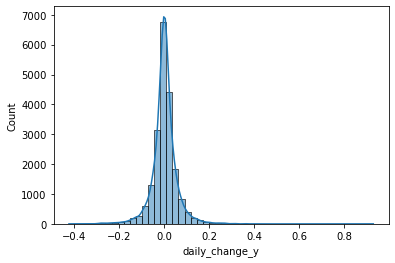

In [4]:
sns.histplot(df['daily_change_y'], bins=50, kde=True)
# plt.show()
plt.savefig('plots/daily_change.png')

In [6]:
df['Date_x'] = pd.to_datetime(df['Date_x']).dt.date
# df = df[df['Date_x'] > pd.Timestamp('2020-10-01')]

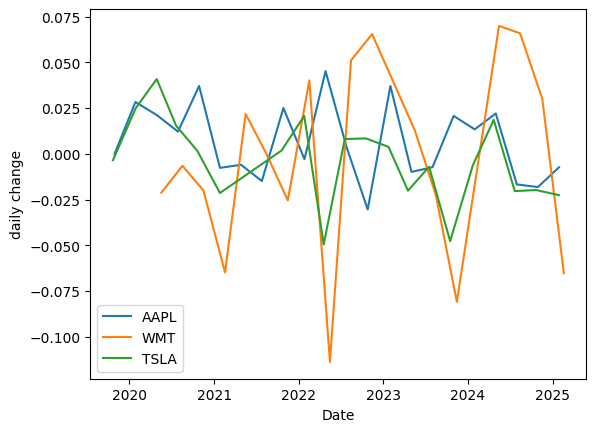

In [7]:
# df = df[['ticker', 'EPS Estimate', 'TTM_EPS', 'PE_Ratio', 'Forward_PE', 'Open', 'High', 'Low', 'Volume', 'daily_change_x', 
#          '1w_change', '1m_change', '3m_change', '1yr_change', '52wk_high', '52wk_low', 'sma20_change', 
#          'sma50_change', 'sma200_change', 'rsi_14', 'volatility_wk', 'volatility_1m', 'Quarter',
#          'Sector', 'Industry', 'HeadquartersState', 'daily_change_y']]

# df = df.dropna()
df = df[df['PE_Ratio'] < 10000]
df = df[df['PE_Ratio'] > -10000]
df['y'] = (df['daily_change_y'] >= 0.03).astype(int)
# df = df[df['1yr_change'] < 10]
# df = df[df['ticker'] != 'BRK-A']
# df = df[df['volatility_wk'] < 100]

tickers = ['AAPL', 'WMT', 'TSLA']
for ticker in tickers:
    subset = df[df['ticker'] == ticker]
    plt.plot(subset['Date_x'], subset['daily_change_y'], label=ticker)

plt.legend()
plt.xlabel('Date')
plt.ylabel('daily change')
plt.show()

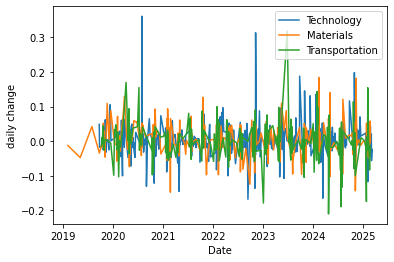

In [208]:
for ticker in df['Sector'].unique()[:3]:
    subset = df[df['Sector'] == ticker].groupby('Date_x').agg({'daily_change_y': 'mean'}).reset_index()
    plt.plot(subset['Date_x'], subset['daily_change_y'], label=ticker)

plt.legend()
plt.xlabel('Date')
plt.ylabel('daily change')
plt.show()

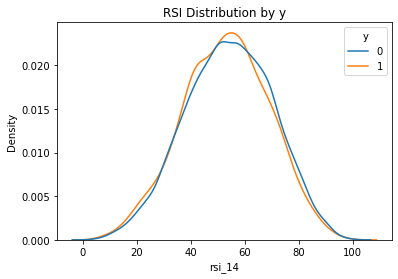

In [209]:
sns.kdeplot(data=df, x="rsi_14", hue="y", common_norm=False)
plt.title("RSI Distribution by y")
plt.show()

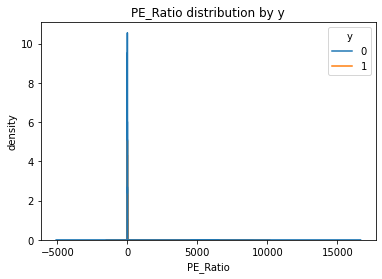

In [12]:
features = ['rsi_14', '1w_change', '1m_change', '3m_change',
       '1yr_change', 'sma20_change', 'sma50_change', 'sma200_change',
       'volatility_wk', 'volatility_1m', 'PE_Ratio']  # your key features

for feature in features:
    sns.kdeplot(data=df, x=feature, hue="y", common_norm=False)
    plt.title(f"{feature} distribution by y")
    plt.xlabel(feature)
    plt.ylabel("density")
#     plt.show()
    plt.savefig(f'plots/{feature}_distribution.png')

In [170]:
df['volatility_1m'].max()

218.41302380961545

In [167]:
df[df['volatility_wk'] > 50][['ticker', 'volatility_wk', 'volatility_1m', 'daily_change_y']]

,ticker,volatility_wk,volatility_1m,daily_change_y
2116,AZO,69.683279,66.854062,0.006964
2654,BKNG,54.349452,127.702127,0.035658
2658,BKNG,65.518037,107.456976,-0.019216
2659,BKNG,78.016144,58.219963,-0.001235
2670,BKNG,58.578914,158.237214,-0.018074
7350,FCNCA,59.980992,35.237225,0.074498
13471,NVR,61.694711,184.564411,-0.035563
13473,NVR,80.375273,191.715349,0.034953
13475,NVR,76.336999,147.658508,-0.021650
13479,NVR,74.737971,138.746734,0.014219


In [130]:
df[df['1yr_change'] > 10]

,Earnings Date,EPS Estimate,Reported EPS,Surprise(%),ticker,Date_x,Quarter,Close,High,Low,...,shifted_rep_eps,TTM_EPS,PE_Ratio,Forward_PE,Ticker,Sector,Industry,HeadquartersCity,HeadquartersState,y
1226,2022-05-04 20:00:00-04:00,19.04,20.52,7.77,AMR,2022-05-04,2,154.718048,159.398139,147.621987,...,4.40,NaN,NaN,8.125948,AMR,Energy,"Mining, Crude-Oil Production",Bristol,Tennessee,1
3815,2021-08-02 20:00:00-04:00,2.40,2.76,14.95,CHRD,2021-08-02,3,60.444828,64.346481,59.669979,...,NaN,NaN,NaN,25.185345,CHRD,Energy,"Mining, Crude-Oil Production",Houston,Texas,0
3816,2021-11-02 20:00:00-04:00,1.82,3.16,73.58,CHRD,2021-11-02,4,85.272728,86.174761,83.702785,...,2.76,NaN,NaN,46.853147,CHRD,Energy,"Mining, Crude-Oil Production",Houston,Texas,0
5193,2024-04-30 20:00:00-04:00,-0.74,0.23,131.14,CVNA,2024-04-30,2,82.919998,83.629997,80.070000,...,-1.00,-3.52,-23.556818,-112.054052,CVNA,Retailing,"Automotive Retailing, Services",Tempe,Arizona,1
8352,2021-03-22 20:00:00-04:00,0.34,0.34,-1.10,GME,2021-03-22,1,48.622501,52.590000,46.549999,...,-0.13,-0.56,-86.825895,143.007357,GME,Retailing,Specialty Retailers: Other,Grapevine,Texas,0
8353,2021-06-08 20:00:00-04:00,-0.21,-0.11,46.11,GME,2021-06-08,2,75.000000,86.165001,70.250000,...,0.34,-0.54,-138.888889,-357.142857,GME,Retailing,Specialty Retailers: Other,Grapevine,Texas,0
8354,2021-09-07 20:00:00-04:00,-0.17,-0.19,-14.29,GME,2021-09-07,3,49.750000,52.474998,49.025002,...,-0.11,-0.25,-199.000000,-292.647059,GME,Retailing,Specialty Retailers: Other,Grapevine,Texas,0


In [9]:
cols_to_scale = ['PE_Ratio', 'Forward_PE', 'Open', 'High', 'Low', 'Volume', '52wk_high', '52wk_low', 'rsi_14']
scaler = StandardScaler().fit(x_train[cols_to_scale])
x_train[cols_to_scale] = scaler.transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

NameError: name 'x_train' is not defined

In [10]:
# df = df[abs(df['daily_change_y']) >= 0.015]


df = df[['ticker', 'EPS Estimate', 'TTM_EPS', 'PE_Ratio', 'Forward_PE', 'Open', 'High', 'Low', 'Volume',
         '1w_change', '1m_change', '3m_change', '1yr_change', '52wk_high', '52wk_low', 'sma20_change', 
         'sma50_change', 'sma200_change', 'rsi_14', 'volatility_wk', 'volatility_1m', 'Quarter',
         'Sector', 'Industry', 'HeadquartersState', 'y']]

df = df.dropna()
df = df[df['PE_Ratio'] < 10000]
df = df[df['PE_Ratio'] > -10000]
# df = df[abs(df['y']) >= 0.02]
print(df['y'].sum() / len(df))

df.shape

0.20773809523809525


(16800, 26)

In [18]:
df.to_csv('data/training_data.csv', index=False)

In [172]:
df[abs(df['daily_change_y']) >= 0.02].shape

KeyError: 'daily_change_y'

In [11]:
X = df.drop(columns=['y', 'ticker'])
X = pd.get_dummies(X)
y = df['y']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=31)

In [214]:
## show all columns
pd.set_option('display.max_columns', None)
df.describe()

,EPS Estimate,TTM_EPS,PE_Ratio,Forward_PE,Open,High,Low,Volume,daily_change_x,1w_change,1m_change,3m_change,1yr_change,52wk_high,52wk_low,sma20_change,sma50_change,sma200_change,rsi_14,volatility_wk,volatility_1m,Quarter,y
count,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,1.680000e+04,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000
mean,7.360002,29.163939,19.014805,72.917037,666.716894,673.300082,660.223663,4.812759e+06,0.001468,0.005808,0.028702,0.042923,0.197814,732.997288,512.671656,0.010571,0.015429,0.049172,53.874390,7.382089,13.902856,2.503929,0.207738
std,172.138798,674.366945,153.134390,458.394575,16410.390381,16552.594221,16257.143151,1.869504e+07,0.025177,0.055190,0.114943,0.226536,0.834263,17723.794927,12905.741947,0.057455,0.088861,0.199224,16.160610,177.598704,323.927235,1.149613,0.405700
min,-10.520000,-53.700000,-5013.750076,-16038.000488,0.415000,0.455100,0.402400,2.000000e+02,-0.398990,-0.722051,-0.831650,-0.861240,-0.955145,1.730000,0.360000,-0.760019,-0.819607,-0.829047,3.338800,0.010415,0.023843,1.000000,0.000000
25%,0.420000,1.960000,8.633254,35.919354,31.991181,32.480185,31.453908,7.111000e+05,-0.010418,-0.021400,-0.031235,-0.069266,-0.100343,40.550133,21.068572,-0.018868,-0.030787,-0.057535,42.518791,0.457140,0.925318,1.000000,0.000000
50%,0.960000,4.080000,15.005067,61.809672,64.661754,65.764171,63.839688,1.724600e+06,0.001226,0.005553,0.021648,0.029305,0.107271,77.674285,44.631424,0.009873,0.015358,0.044546,54.174306,0.929828,1.839680,3.000000,0.000000
75%,1.870000,7.632500,23.764586,99.463810,129.340538,131.137482,127.732502,4.051600e+06,0.012851,0.031693,0.077710,0.136675,0.356231,151.679647,90.065555,0.038916,0.061073,0.146338,65.577671,1.974292,3.783811,4.000000,0.000000
max,6868.240000,29184.000000,6444.000244,13189.999390,721103.000000,725552.000000,716742.000000,7.552930e+08,0.474501,1.058823,3.791574,12.114633,58.880237,741971.000000,596000.000000,0.752669,1.627598,4.324525,99.439531,8882.455443,16503.411052,4.000000,1.000000


In [12]:
cols_to_scale = ['PE_Ratio', 'Forward_PE', 'Open', 'High', 'Low', 'Volume', '52wk_high', '52wk_low', 'rsi_14']
scaler = StandardScaler().fit(x_train[cols_to_scale])
x_train[cols_to_scale] = scaler.transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

In [193]:
x_train.head()

,EPS Estimate,TTM_EPS,PE_Ratio,Forward_PE,Open,High,Low,Volume,daily_change_x,1w_change,1m_change,3m_change,1yr_change,52wk_high,52wk_low,sma20_change,sma50_change,sma200_change,rsi_14,volatility_wk,volatility_1m,Quarter,Sector_Aerospace & Defense,Sector_Apparel,Sector_Business Services,Sector_Chemicals,Sector_Energy,Sector_Engineering & Construction,Sector_Financials,Sector_Food & Drug Stores,"Sector_Food, Beverages & Tobacco",Sector_Health Care,"Sector_Hotels, Restaurants & Leisure",Sector_Household Products,Sector_Industrials,Sector_Materials,Sector_Media,Sector_Motor Vehicles & Parts,Sector_Retailing,Sector_Technology,Sector_Telecommunications,Sector_Transportation,Sector_Wholesalers,"Industry_Advertising, marketing",Industry_Aerospace & Defense,Industry_Airlines,Industry_Apparel,"Industry_Automotive Retailing, Services",Industry_Beverages,"Industry_Building Materials, Glass",Industry_Chemicals,Industry_Commercial Banks,Industry_Computer Software,"Industry_Computers, Office Equipment",Industry_Construction and Farm Machinery,Industry_Diversified Financials,Industry_Diversified Outsourcing Services,Industry_Education,"Industry_Electronics, Electrical Equip.",Industry_Energy,Industry_Engineering & Construction,Industry_Entertainment,Industry_Equipment Leasing,Industry_Financial Data Services,Industry_Food & Drug Stores,Industry_Food Consumer Products,Industry_Food Production,Industry_Food Services,Industry_Forest and Paper Products,Industry_General Merchandisers,Industry_Health Care: Insurance and Managed Care,Industry_Health Care: Medical Facilities,Industry_Health Care: Pharmacy and Other Services,"Industry_Home Equipment, Furnishings",Industry_Homebuilders,"Industry_Hotels, Casinos, Resorts",Industry_Household and Personal Products,Industry_Industrial Machinery,Industry_Information Technology Services,"Industry_Insurance: Life, Health (stock)",Industry_Insurance: Property and Casualty (Stock),Industry_Internet Services and Retailing,"Industry_Mail, Package, and Freight Delivery",Industry_Medical Products and Equipment,Industry_Metals,"Industry_Mining, Crude-Oil Production",Industry_Miscellaneous,Industry_Motor Vehicles & Parts,Industry_Network and Other Communications Equipment,"Industry_Oil and Gas Equipment, Services","Industry_Packaging, Containers",Industry_Petroleum Refining,Industry_Pharmaceuticals,Industry_Pipelines,"Industry_Publishing, Printing",Industry_Railroads,Industry_Real estate,"Industry_Scientific,Photographic and Control Equipment",Industry_Securities,Industry_Semiconductors and Other Electronic Components,Industry_Shipping,Industry_Specialty Retailers: Apparel,Industry_Specialty Retailers: Other,Industry_Telecommunications,Industry_Temporary Help,Industry_Tobacco,"Industry_Toys, Sporting Goods",Industry_Transportation Equipment,Industry_Transportation and Logistics,"Industry_Trucking, Truck Leasing",Industry_Utilities: Gas and Electric,Industry_Waste Management,Industry_Wholesalers: Diversified,Industry_Wholesalers: Electronics and Office Equipment,Industry_Wholesalers: Food and Grocery,Industry_Wholesalers: Health Care,HeadquartersState_Alabama,HeadquartersState_Arizona,HeadquartersState_Arkansas,HeadquartersState_California,HeadquartersState_Colorado,HeadquartersState_Connecticut,HeadquartersState_Delaware,HeadquartersState_District Of Columbia,HeadquartersState_Florida,HeadquartersState_Georgia,HeadquartersState_Hawaii,HeadquartersState_Idaho,HeadquartersState_Illinois,HeadquartersState_Indiana,HeadquartersState_Iowa,HeadquartersState_Kansas,HeadquartersState_Kentucky,HeadquartersState_Louisiana,HeadquartersState_Maine,HeadquartersState_Maryland,HeadquartersState_Massachusetts,HeadquartersState_Michigan,HeadquartersState_Minnesota,HeadquartersState_Mississippi,HeadquartersState_Missouri,HeadquartersState_Montana,HeadquartersState_Nebraska,HeadquartersState_Nevada,HeadquartersState_New Hampshire,HeadquartersState_New Jersey,HeadquartersState_New York,HeadquartersState_North Carolina,HeadquartersState_

In [187]:
x_train.dtypes

EPS Estimate         float64
TTM_EPS              float64
PE_Ratio             float64
Forward_PE           float64
Open                 float64
High                 float64
Low                  float64
Volume               float64
daily_change_x       float64
1w_change            float64
1m_change            float64
3m_change            float64
1yr_change           float64
52wk_high            float64
52wk_low             float64
sma20_change         float64
sma50_change         float64
sma200_change        float64
rsi_14               float64
volatility_wk        float64
volatility_1m        float64
Quarter                int64
Sector                object
Industry              object
HeadquartersState     object
dtype: object

In [242]:
clf = LogisticRegression(max_iter=1000).fit(x_train, y_train)
clf.score(x_test, y_test)

print(roc_auc_score(y_test, clf.predict_proba(x_test)[:, 1]))
print(f1_score(y_test, clf.predict(x_test)))
print(classification_report(y_test, clf.predict(x_test)))

0.6321987366375121
0.0047281323877068565
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      2940
           1       0.33      0.00      0.00       420

    accuracy                           0.87      3360
   macro avg       0.60      0.50      0.47      3360
weighted avg       0.81      0.87      0.82      3360



c:\Users\samki\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
clf_rf = RandomForestClassifier(n_estimators=1000).fit(x_train, y_train)
preds = clf_rf.predict(x_test)
print(roc_auc_score(y_test, clf_rf.predict_proba(x_test)[:, 1]))
print(f1_score(y_test, preds))
print(classification_report(y_test, preds))


0.6449493040041244
0.024193548387096774
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      2645
           1       0.31      0.01      0.02       715

    accuracy                           0.78      3360
   macro avg       0.55      0.50      0.45      3360
weighted avg       0.69      0.78      0.70      3360



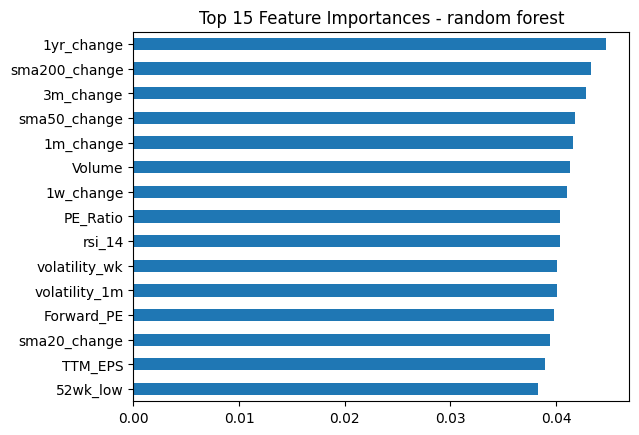

In [16]:
importances = pd.Series(clf_rf.feature_importances_, index=x_train.columns).sort_values(ascending=False)

importances.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances - random forest")
plt.gca().invert_yaxis()
# plt.show()
plt.savefig('plots/top_15_feature_rf.png')

In [14]:
xgb_params = {
    'n_estimators': 5000,
    'learning_rate': 0.01,
    'booster': 'gbtree',
    'max_depth': 6,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'early_stopping_rounds': 250
}
clf_xgb = xgb.XGBClassifier(**xgb_params)
clf_xgb.fit(x_train, y_train, eval_set=[(x_test, y_test)], verbose=100)
preds = clf_xgb.predict(x_test)
print(roc_auc_score(y_test, clf_xgb.predict_proba(x_test)[:, 1]))
print(f1_score(y_test, preds))
print(classification_report(y_test, preds))


[0]	validation_0-aucpr:0.24599
[100]	validation_0-aucpr:0.27173
[200]	validation_0-aucpr:0.27458
[300]	validation_0-aucpr:0.28019
[400]	validation_0-aucpr:0.28219
[500]	validation_0-aucpr:0.28403
[600]	validation_0-aucpr:0.28484
[700]	validation_0-aucpr:0.28558
[800]	validation_0-aucpr:0.28605
[900]	validation_0-aucpr:0.28674
[1000]	validation_0-aucpr:0.28616
[1100]	validation_0-aucpr:0.28591
[1139]	validation_0-aucpr:0.28576
0.6349317223419302
0.02663115845539281
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      2645
           1       0.28      0.01      0.03       715

    accuracy                           0.78      3360
   macro avg       0.53      0.50      0.45      3360
weighted avg       0.68      0.78      0.70      3360



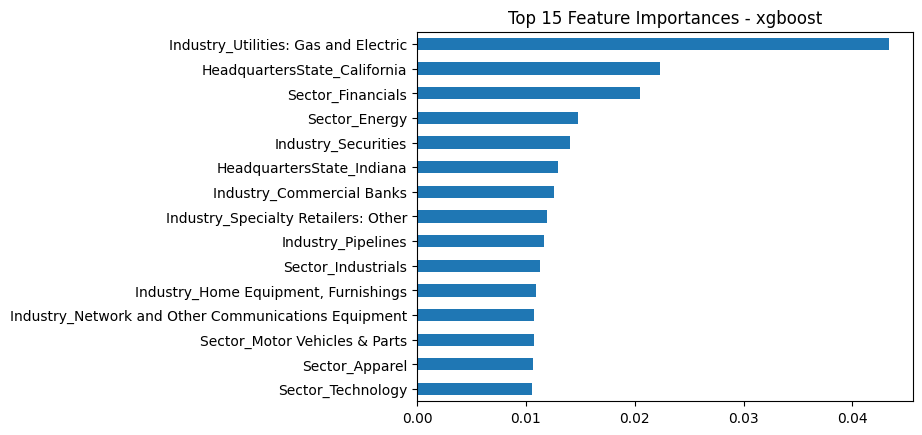

In [15]:
importances = pd.Series(clf_xgb.feature_importances_, index=x_train.columns).sort_values(ascending=False)

importances.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances - xgboost")
plt.gca().invert_yaxis()
# plt.show()
plt.savefig('plots/top_15_feature_xgboost.png')

In [ ]:
cat_feats = ['Quarter', 'Sector', 'Industry', 'HeadquartersState']
train_pool = Pool(x_train, y_train, cat_features=cat_feats)
test_pool = Pool(x_test, y_test, cat_features=cat_feats)

clf_cat = CatBoostClassifier(iterations=5000, learning_rate=0.01, depth=5, eval_metric='AUC', early_stopping_rounds=250)
clf_cat.fit(train_pool, eval_set=test_pool, verbose=100)
preds = clf_cat.predict(test_pool)
print(roc_auc_score(y_test, clf_cat.predict_proba(test_pool)[:, 1]))
print(f1_score(y_test, preds))
print(classification_report(y_test, preds))


0:	test: 0.5503294	best: 0.5503294 (0)	total: 107ms	remaining: 8m 53s
100:	test: 0.5922738	best: 0.5922959 (99)	total: 7.59s	remaining: 6m 8s
200:	test: 0.6179254	best: 0.6179254 (200)	total: 15.4s	remaining: 6m 7s
300:	test: 0.6492626	best: 0.6492626 (300)	total: 23.1s	remaining: 6m 1s
400:	test: 0.6549814	best: 0.6549814 (400)	total: 31s	remaining: 5m 55s
500:	test: 0.6581331	best: 0.6581470 (497)	total: 38.5s	remaining: 5m 46s
600:	test: 0.6593749	best: 0.6594751 (563)	total: 46.4s	remaining: 5m 39s
700:	test: 0.6605950	best: 0.6606919 (687)	total: 54.4s	remaining: 5m 33s
800:	test: 0.6617144	best: 0.6617515 (798)	total: 1m 1s	remaining: 5m 24s
900:	test: 0.6626478	best: 0.6627142 (899)	total: 1m 9s	remaining: 5m 17s
1000:	test: 0.6632291	best: 0.6633232 (991)	total: 1m 17s	remaining: 5m 10s
1100:	test: 0.6643136	best: 0.6643136 (1100)	total: 1m 25s	remaining: 5m 2s
1200:	test: 0.6641547	best: 0.6645273 (1111)	total: 1m 33s	remaining: 4m 55s
1300:	test: 0.6639023	best: 0.6645273 (11

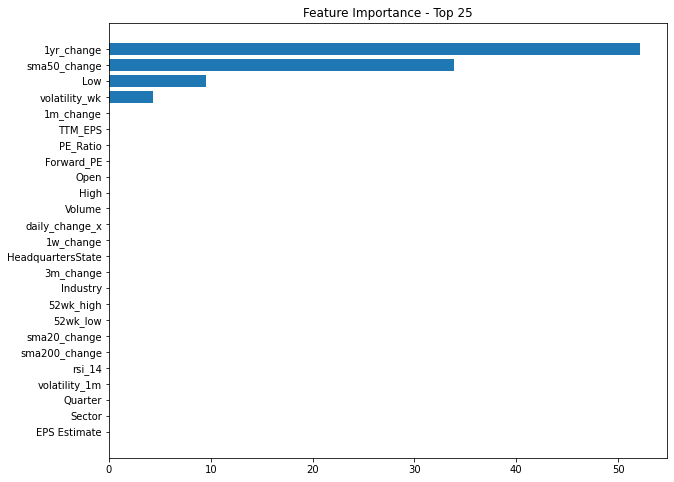

In [79]:
TOP = 25

feature_importance = clf_cat.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(10, 8))
plt.barh(np.arange(len(sorted_idx))[-TOP:], feature_importance[sorted_idx][-TOP:], align='center')
plt.yticks(np.arange(len(sorted_idx))[-TOP:], np.array(x_train.columns)[sorted_idx][-TOP:])
plt.title(f'Feature Importance - Top {TOP}')
plt.show()